# Drug Response Classification

## Pharmaceutical Industry – Machine Learning Classification

### Business Context

Pharmaceutical companies invest heavily in clinical trials to test drug efficacy. However, a drug may not work for every patient because of differences in biology, metabolism, and pre-existing conditions. Traditional clinical trials can take years and involve high costs and risks.

A machine learning classification model can be used to predict whether a patient is likely to show a positive response to a drug. This can support earlier decision-making and is relevant to personalized medicine.

**Classification labels used in this dataset:

0 = No Response

1 = Positive Response


## Objective

The aim of this analysis is to build a classification workflow using the supplied pharmaceutical dataset.

The workflow includes:

1. Loading and understanding the dataset.
2. Checking data quality and missing values.
3. Exploring the target variable and predictor variables.
4. Splitting the data into training and testing sets.
5. Training classification models.
6. Evaluating model performance using appropriate classification metrics.
7. Looking at the confusion matrix and feature importance.
8. Interpreting the results in the pharmaceutical context.


In [3]:
# Importing the libraries used in this analysis
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Load the supplied dataset
df = pd.read_csv("Pharma_Industry.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())


Dataset loaded successfully.
Shape: (500, 6)


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


## 1. Understanding the dataset

The dataset contains 500 observations and 6 columns. There are five predictor variables:

- Drug Dosage (mg)
- Systolic Blood Pressure (mmHg)
- Heart Rate (BPM)
- Liver Toxicity Index (U/L)
- Blood Glucose Level (mg/dL)

The sixth column, **Drug Response**, is the target variable.

The target follows the classification definition from the assignment:
- 0 = No Response
- 1 = Positive Response


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nSummary statistics:")
display(df.describe().T)


Rows: 500
Columns: 6

Column names:
['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)', 'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)', 'Blood Glucose Level (mg/dL)', 'Drug Response']

Data types:


,Data Type
Drug Dosage (mg),float64
Systolic Blood Pressure (mmHg),float64
Heart Rate (BPM),float64
Liver Toxicity Index (U/L),float64
Blood Glucose Level (mg/dL),float64
Drug Response,int64



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Drug Dosage (mg),500.0,-0.037761,0.979891,-3.019512,-0.642003,-0.019340,0.641151,2.949094
Systolic Blood Pressure (mmHg),500.0,0.214957,1.247567,-3.773897,-0.565168,0.201532,0.951375,4.111751
Heart Rate (BPM),500.0,0.062871,0.971978,-2.940389,-0.648157,0.027732,0.710774,3.193108
Liver Toxicity Index (U/L),500.0,0.054398,0.986001,-3.401277,-0.586085,-0.065661,0.633914,3.373269
Blood Glucose Level (mg/dL),500.0,-0.171863,0.983765,-3.110431,-0.797715,-0.108106,0.513555,2.518023
Drug Response,500.0,0.520000,0.500100,0.000000,0.000000,1.000000,1.000000,1.000000


## 2. Data quality checks

Before fitting a model, I checked for missing values, duplicated rows, and unusual data types.

The dataset supplied with the assignment contains numerical predictor variables and an integer binary target. No missing values were found in the supplied data.


In [5]:
# Missing-value check
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

display(missing)

# Duplicate check
print("Number of duplicate rows:", df.duplicated().sum())

# Unique target values
print("\nUnique Drug Response values:", sorted(df["Drug Response"].unique()))


,Missing Count,Missing Percentage
Drug Dosage (mg),0,0.0
Systolic Blood Pressure (mmHg),0,0.0
Heart Rate (BPM),0,0.0
Liver Toxicity Index (U/L),0,0.0
Blood Glucose Level (mg/dL),0,0.0
Drug Response,0,0.0


Number of duplicate rows: 0

Unique Drug Response values: [np.int64(0), np.int64(1)]


## 3. Exploratory data analysis

I first looked at the distribution of the response variable. This is important because if one class is much larger than the other, accuracy alone may not give a complete picture of model performance.


,Count,Percentage
Drug Response,,
0,240,48.0
1,260,52.0


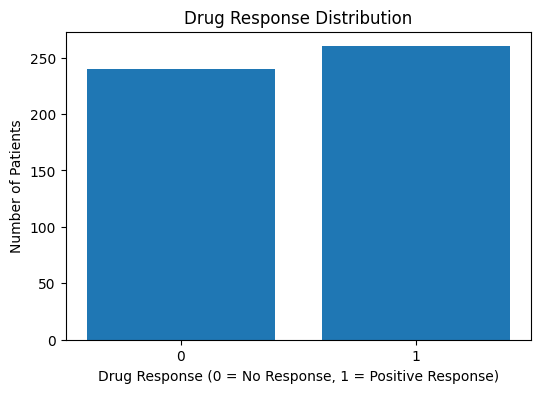

In [6]:
response_counts = df["Drug Response"].value_counts().sort_index()
response_percent = (response_counts / len(df) * 100).round(2)

target_summary = pd.DataFrame({
    "Count": response_counts,
    "Percentage": response_percent
})

display(target_summary)

plt.figure(figsize=(6, 4))
plt.bar(target_summary.index.astype(str), target_summary["Count"])
plt.title("Drug Response Distribution")
plt.xlabel("Drug Response (0 = No Response, 1 = Positive Response)")
plt.ylabel("Number of Patients")
plt.show()


### Interpretation

The target distribution above shows how many observations belong to each response category. I would check this before interpreting accuracy because a strongly imbalanced target could make a model appear better than it actually is.

In this dataset, both response classes are represented, so the classification problem can be evaluated using multiple metrics rather than relying on accuracy alone.


## 4. Distribution of the predictor variables

The supplied predictor values are already on relatively standardized-looking numerical scales. Even so, I will use `StandardScaler` inside the Logistic Regression pipeline. Keeping the scaler inside the pipeline is important because the scaling parameters are learned only from the training data.


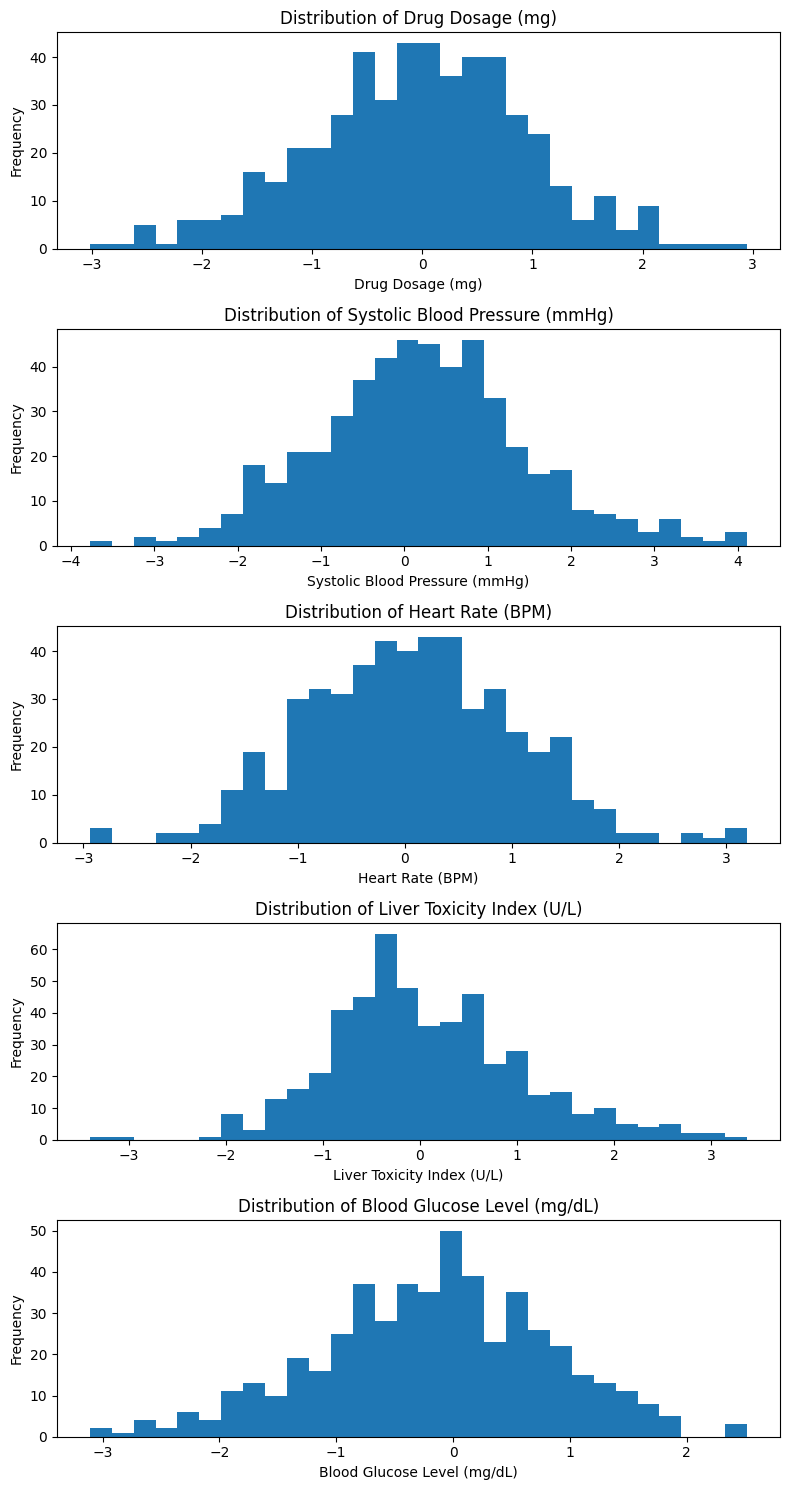

In [7]:
feature_cols = [
    "Drug Dosage (mg)",
    "Systolic Blood Pressure (mmHg)",
    "Heart Rate (BPM)",
    "Liver Toxicity Index (U/L)",
    "Blood Glucose Level (mg/dL)"
]

fig, axes = plt.subplots(5, 1, figsize=(8, 15))

for ax, col in zip(axes, feature_cols):
    ax.hist(df[col], bins=30)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


## 5. Comparing predictor averages by drug response

A useful first exploration is to compare the average value of each predictor for response = 0 and response = 1.

This does not prove that a variable causes the response. It only shows whether the two groups have noticeably different average values, which can give some initial intuition about potentially useful predictors.


In [8]:
group_means = df.groupby("Drug Response")[feature_cols].mean().T
display(group_means)

# Difference between positive-response and no-response group means
group_means["Difference (1 - 0)"] = group_means[1] - group_means[0]
display(group_means)


Drug Response,0,1
Drug Dosage (mg),-0.082039,0.003111
Systolic Blood Pressure (mmHg),-0.180985,0.580442
Heart Rate (BPM),0.072690,0.053808
Liver Toxicity Index (U/L),-0.391294,0.465806
Blood Glucose Level (mg/dL),-0.345085,-0.011967


Drug Response,0,1,Difference (1 - 0)
Drug Dosage (mg),-0.082039,0.003111,0.085150
Systolic Blood Pressure (mmHg),-0.180985,0.580442,0.761427
Heart Rate (BPM),0.072690,0.053808,-0.018881
Liver Toxicity Index (U/L),-0.391294,0.465806,0.857100
Blood Glucose Level (mg/dL),-0.345085,-0.011967,0.333118


## 6. Train-test split

I separate the predictors (`X`) from the response (`y`) and split the dataset into training and testing subsets.

I use an **80/20 split** with `stratify=y`. Stratification keeps approximately the same proportion of response classes in both subsets.

The 80/20 split is a modelling choice because the assignment document does not prescribe a specific split ratio.


In [9]:
X = df[feature_cols].copy()
y = df["Drug Response"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


Training observations: 400
Testing observations: 100

Training target distribution:
Drug Response
0    0.48
1    0.52
Name: proportion, dtype: float64

Testing target distribution:
Drug Response
0    0.48
1    0.52
Name: proportion, dtype: float64


## 7. Model 1 – Logistic Regression

Logistic Regression is a good baseline for a binary classification problem. It estimates the probability of belonging to class 1 and then converts that probability into a class prediction.

Because Logistic Regression is sensitive to feature scale, I use StandardScaler before the classifier. The scaler and model are kept together in a pipeline.


In [10]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

y_pred_log = logistic_model.predict(X_test)
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")


Logistic Regression trained successfully.


## 8. Logistic Regression evaluation

For this classification task, I report:

- **Accuracy:** overall proportion of correct predictions.
- **Precision:** among observations predicted as positive response, how many were actually positive.
- **Recall:** among actual positive responses, how many were correctly identified.
- **F1-score:** harmonic mean of precision and recall.
- **ROC-AUC:** measures the model's ability to rank positive cases above negative cases across probability thresholds.



In [11]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_log,
    y_prob_log
)

display(pd.DataFrame([logistic_results]).round(4))

print("Classification report:")
print(classification_report(
    y_test,
    y_pred_log,
    target_names=["No Response (0)", "Positive Response (1)"],
    zero_division=0
))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.71,0.7347,0.6923,0.7129,0.7897


Classification report:
                       precision    recall  f1-score   support

      No Response (0)       0.69      0.73      0.71        48
Positive Response (1)       0.73      0.69      0.71        52

             accuracy                           0.71       100
            macro avg       0.71      0.71      0.71       100
         weighted avg       0.71      0.71      0.71       100



## 9. Logistic Regression confusion matrix


Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,35,13
Actual 1,16,36


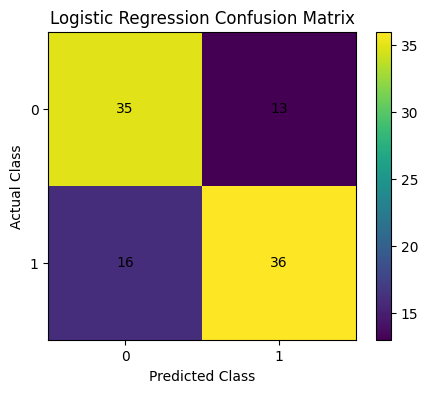

In [12]:
cm_log = confusion_matrix(y_test, y_pred_log)

print("Confusion matrix:")
display(pd.DataFrame(
    cm_log,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

plt.figure(figsize=(5, 4))
plt.imshow(cm_log)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_log[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


## 10. Model 2 – Random Forest

As a second model, I use Random Forest. It combines many decision trees and can capture non-linear relationships and interactions between predictors.

Unlike Logistic Regression, Random Forest does not require the predictors to have a linear relationship with the target. It also does not require feature scaling, so it is useful as a comparison model.


In [13]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=None
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

display(pd.DataFrame([rf_results]).round(4))

print("Classification report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Response (0)", "Positive Response (1)"],
    zero_division=0
))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.76,0.75,0.8077,0.7778,0.8231


Classification report:
                       precision    recall  f1-score   support

      No Response (0)       0.77      0.71      0.74        48
Positive Response (1)       0.75      0.81      0.78        52

             accuracy                           0.76       100
            macro avg       0.76      0.76      0.76       100
         weighted avg       0.76      0.76      0.76       100



## 11. Random Forest confusion matrix


Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,34,14
Actual 1,10,42


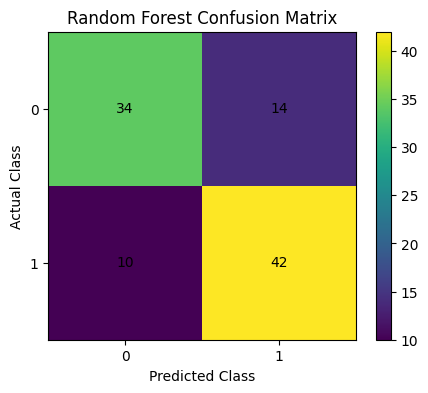

In [14]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion matrix:")
display(pd.DataFrame(
    cm_rf,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

plt.figure(figsize=(5, 4))
plt.imshow(cm_rf)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


## 12. Compare the models

Putting the metrics together makes the comparison easier. I would not select a model from accuracy alone. In a healthcare/pharmaceutical application, the balance between false positives and false negatives is important.


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.71,0.7347,0.6923,0.7129,0.7897
Random Forest,0.76,0.7500,0.8077,0.7778,0.8231


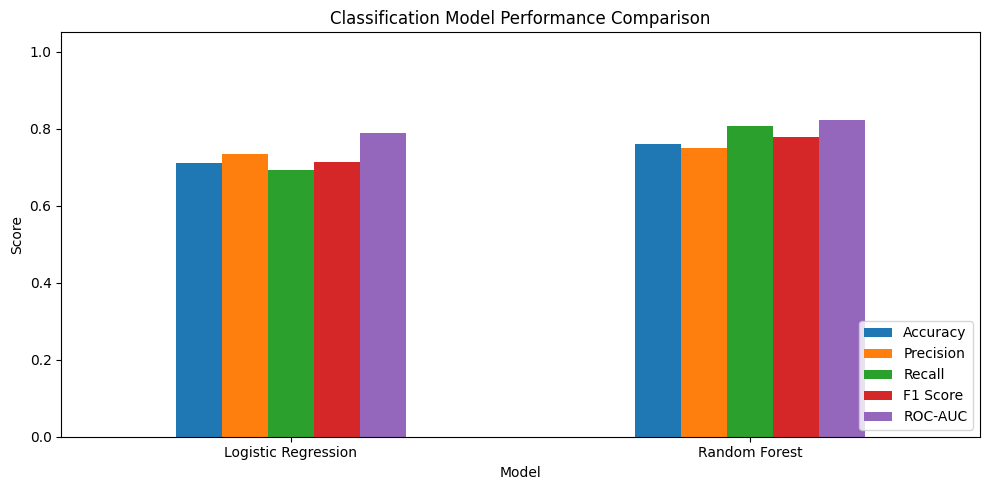

In [15]:
results = pd.DataFrame([
    logistic_results,
    rf_results
]).set_index("Model")

display(results.round(4))

# Plot the main metrics for easier comparison
metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

ax = results[metric_cols].plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Classification Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 13. ROC curve

The ROC curve shows the trade-off between the true-positive rate and false-positive rate at different probability thresholds.

The area under the ROC curve (ROC-AUC) is also reported. A higher value indicates better separation between the two response classes.


<Figure size 700x500 with 0 Axes>

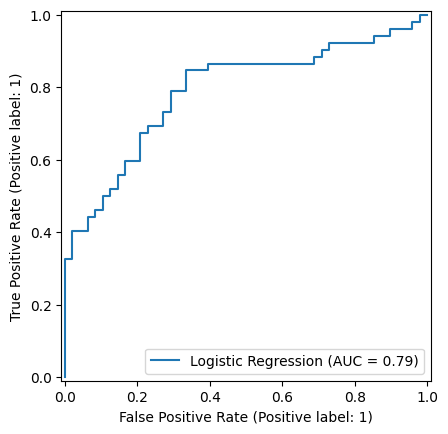

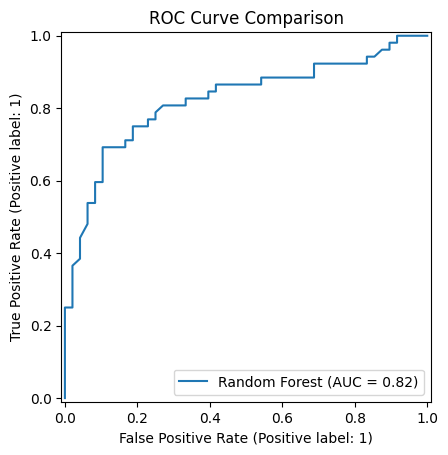

In [16]:
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.show()


## 14. Feature importance

Random Forest provides feature-importance values based on how much the features contribute to reducing impurity across the trees.

These values are useful for interpretation, but they should not be treated as proof that a feature causes drug response.


,Random Forest Importance
Liver Toxicity Index (U/L),0.327522
Systolic Blood Pressure (mmHg),0.226022
Blood Glucose Level (mg/dL),0.203203
Heart Rate (BPM),0.128302
Drug Dosage (mg),0.114951


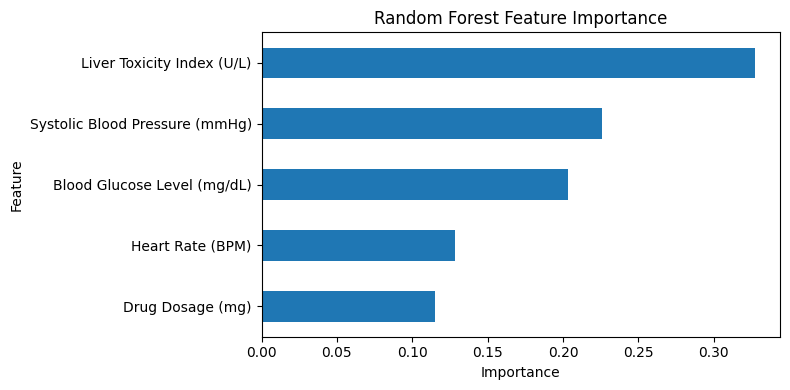

In [17]:
importance = pd.Series(
    random_forest.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

display(importance.to_frame("Random Forest Importance"))

plt.figure(figsize=(8, 4))
importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 15. Logistic Regression coefficients

The Logistic Regression coefficients provide another way to inspect the relationship between predictors and the predicted probability of a positive response.

Because the features are standardized inside the pipeline, the coefficient magnitudes are easier to compare with each other.

- A positive coefficient pushes the prediction toward class 1.
- A negative coefficient pushes the prediction toward class 0.
- Larger absolute values indicate a stronger model coefficient, although this still should not be interpreted as causal evidence.


,Coefficient
Heart Rate (BPM),-0.062674
Drug Dosage (mg),0.038481
Blood Glucose Level (mg/dL),0.171646
Systolic Blood Pressure (mmHg),0.559501
Liver Toxicity Index (U/L),1.010150


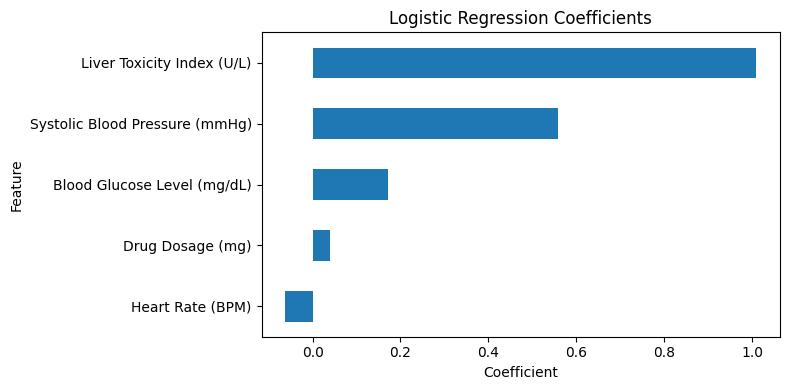

In [18]:
log_coefficients = pd.Series(
    logistic_model.named_steps["classifier"].coef_[0],
    index=feature_cols
).sort_values()

display(log_coefficients.to_frame("Coefficient"))

plt.figure(figsize=(8, 4))
log_coefficients.plot(kind="barh")
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 16. Error analysis

The incorrect predictions are particularly useful in a classification problem because they show where the model is uncertain or where the available variables may not be sufficient to explain the response.

I inspect the test observations that were misclassified by the better-performing model according to the metric comparison above.


In [19]:
# Select the model with the higher F1 score for a simple error-analysis example.
best_model_name = results["F1 Score"].idxmax()

if best_model_name == "Logistic Regression":
    best_predictions = y_pred_log
else:
    best_predictions = y_pred_rf

errors = X_test.copy()
errors["Actual Response"] = y_test.values
errors["Predicted Response"] = best_predictions
errors = errors[errors["Actual Response"] != errors["Predicted Response"]]

print("Model selected for error analysis:", best_model_name)
print("Number of misclassified test observations:", len(errors))

display(errors.head(15))


Model selected for error analysis: Random Forest
Number of misclassified test observations: 24


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Actual Response,Predicted Response
170,-0.426358,-0.016168,1.148446,1.024610,0.802683,0,1
324,-0.019420,-0.003110,-0.303180,0.231979,-0.313296,1,0
180,0.586694,0.424681,-0.474904,0.533145,0.770250,0,1
499,-1.143726,0.715320,0.108560,-0.509787,-0.250704,1,0
293,0.919229,-0.236953,-0.668144,-0.039537,-0.999844,0,1
411,0.579633,0.228161,0.325796,0.788689,0.716748,0,1
95,-0.544114,-1.358062,-0.162793,-0.708297,1.211312,0,1
228,0.403730,-0.809395,-0.024196,0.597601,-1.005574,0,1
60,0.020794,-0.203236,-0.728003,0.615898,-0.031934,0,1
472,-1.875172,-0.464567,0.115026,-0.516983,-1.810083,1,0


## 17. Business interpretation

The assignment explains that drug response classification is important because pharmaceutical companies can use it when evaluating drug effectiveness, while personalized medicine aims to match treatment decisions with individual patient responses.

In this dataset, the model uses dosage and several biological measurements to predict whether the response is:

No Response:the drug did not produce a significant effect.
Positive Response: the patient showed a beneficial response.

A model with good predictive performance could potentially help identify patients who are more likely to respond positively. However, the model should be viewed as a predictive support tool rather than a replacement for clinical trials or medical judgment.



## 18. Final conclusion

After exploring the data, I trained two binary classification models: Logistic Regression and Random Forest.

The model comparison table above should be used to identify which model performs better on the held-out test data. The decision should consider accuracy together with precision, recall, F1-score, and ROC-AUC.

For this pharmaceutical problem, I would pay particular attention to **recall for the positive-response class**, because a false negative means that a patient who could respond positively is predicted as a non-responder. At the same time, precision should also be considered because false-positive predictions can have practical consequences.

The final model choice should therefore be based on the evaluation results rather than simply choosing the more complex algorithm.

### Limitations

This dataset contains only five predictor variables. Real drug-response prediction would normally require substantially more patient and clinical information. The assignment document itself explains that individual biology, metabolism, and pre-existing conditions can influence whether a drug works. fileciteturn1file0L2-L8

Therefore, even a high test score on this dataset should not be interpreted as evidence that the model is clinically ready. External validation, appropriate clinical study design, and domain expertise would be required before practical use.
